# DOM 48장 회전 보정 파이프라인 (정본)

**목적:** ATRNet-STAR Sandstone DOM 풀씬 **48장(방위각 12 × 편파 4)** 전부에
탐지(YOLO+SAHI) + 분류 + **회전 보정**을 적용해 정량평가한다.

## 회전 보정의 원리
DOM은 북쪽 고정 지오코딩 → 비0° 방위각 씬은 학습 칩(그림자=아래 규약)과 어긋난다.
→ **씬을 방위각만큼 회전**해 칩 규약으로 복원 → 탐지·분류 → **박스 좌표만 원래 지도 좌표로 역변환**.
- 회전은 **무손실 90° 단위(np.rot90)** — 보간 화질손상 없음
- 방위각을 가장 가까운 90°로 스냅, **180° 모호성은 E2E로 자동 결정**

## 준비물 (드라이브 `MyDrive/ATRNet-STAR/`)
- `dom_scenes.tar` (DOM 48장 + Annotation xml)
- `checkpoints/yolo_detector.pt`, `checkpoints/{분류기}_soc50_final.pth`
- `results/resnet18_soc50.json` (클래스 순서용, 없으면 soc50.tar에서 자동)
- 런타임 → **T4 GPU** (48장 ≈ 8~15분)

## 분류기 교체
**셀 3** 의 분류기 블록만 바꾸면 됨 (ConvNeXt / ResNet18 / SARATR-X). CSV 파일명도 자동으로 분류기명 반영.

## 1. 환경 준비 + 데이터/메타 로드

In [ ]:
import torch, os, glob, re
from google.colab import drive
drive.mount('/content/drive')
!pip -q install ultralytics sahi

SAVE_DIR = "/content/drive/MyDrive/ATRNet-STAR"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "/", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# DOM 48장 해제
if not os.path.exists("/content/raw_scenes"):
    !cp "{SAVE_DIR}/dom_scenes.tar" /content/dom_scenes.tar
    !tar -xf /content/dom_scenes.tar -C /content/ && rm /content/dom_scenes.tar
dom_tifs = sorted(glob.glob("/content/raw_scenes/**/DOM*.tif", recursive=True))

# 메타 파싱 (방위각/편파)
POLMAP = {"H1H1": "HH", "H1V1": "HV", "V1H1": "VH", "V1V1": "VV"}
def scene_meta(path):
    folder = path.split("/")[-2]              # 예: 30deg_150azi_ID9
    fname  = os.path.basename(path)           # 예: DOM_KuSAR_H1H1_STR1_azbias1024.tif
    azi = int(re.search(r"(\d+)azi", folder).group(1))
    parts = fname.split("_")
    return dict(path=path, folder=folder, azi=azi, pol=POLMAP.get(parts[2], parts[2]))

meta = [scene_meta(p) for p in dom_tifs]
print(f"DOM {len(dom_tifs)}장 | 방위각 {sorted(set(m['azi'] for m in meta))} | 편파 {sorted(set(m['pol'] for m in meta))}")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.1 MB/s eta 0:00:00
device: cpu / CPU
DOM 48장 | 방위각 [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330] | 편파 ['HH', 'HV', 'VH', 'VV']


## 2. 모델 로드 (탐지기 + 분류기)
분류기를 바꾸려면 **이 셀의 분류기 블록만** 교체.

In [ ]:
import json
import torch.nn as nn
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

# ===== 탐지기 (공통) =====
det_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=f"{SAVE_DIR}/checkpoints/yolo_detector.pt",
    confidence_threshold=0.5,
    device="cuda:0" if torch.cuda.is_available() else "cpu",
    image_size=256,
)

# ===== 클래스 순서 (학습 ImageFolder와 동일해야 라벨 안 엉킴) =====
try:
    with open(f"{SAVE_DIR}/results/resnet18_soc50.json") as f:
        CLASS_NAMES = json.load(f)["classes"]
except FileNotFoundError:
    if not os.path.exists("/content/SOC_50classes"):
        !cp "{SAVE_DIR}/soc50.tar" /content/soc50.tar
        !tar -xf /content/soc50.tar -C /content/ && rm /content/soc50.tar
    CLASS_NAMES = sorted(os.listdir("/content/SOC_50classes/test"))
NUM_CLASSES = len(CLASS_NAMES)

# ===== 분류기 (★ 교체 지점 — 셋 중 하나만 활성화) =====
from torchvision.models import convnext_tiny
MODEL_TAG = "convnext"
classifier = convnext_tiny()
classifier.classifier[2] = nn.Linear(classifier.classifier[2].in_features, NUM_CLASSES)
classifier.load_state_dict(torch.load(f"{SAVE_DIR}/checkpoints/convnext_soc50_final.pth", map_location=device))
CLS_RESIZE = 128

# --- ResNet18 ---
# from torchvision.models import resnet18
# MODEL_TAG = "resnet18"
# classifier = resnet18()
# classifier.fc = nn.Linear(classifier.fc.in_features, NUM_CLASSES)
# classifier.load_state_dict(torch.load(f"{SAVE_DIR}/checkpoints/resnet18_soc50_final.pth", map_location=device))
# CLS_RESIZE = 128

classifier = classifier.to(device).eval()
print(f"분류기: {MODEL_TAG} / 클래스 {NUM_CLASSES} / 입력 {CLS_RESIZE}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
분류기: convnext / 클래스 50 / 입력 128


## 3. 공통 함수 — 무손실 회전 + 탐지/분류/평가
- `rot_k`: np.rot90으로 90°×k 회전 (보간 없음)
- `inv_box`: 회전 프레임 박스 → 원본 좌표 (정수 역변환 + 자기검증)
- `eval_at_k` / `correct_rotation`: k회전 후 탐지→GT 매칭, 180° 모호성은 E2E로 결정

In [ ]:
import numpy as np
from PIL import Image
import torchvision.transforms as T
import xml.etree.ElementTree as ET
Image.MAX_IMAGE_PIXELS = None

def load_dom_rgb(path):
    arr = np.array(Image.open(path))
    if arr.dtype != np.uint8:                       # 16bit 대비 안전장치(DOM은 보통 8bit)
        a = arr.astype(np.float32); p = np.percentile(a[a > 0], 99)
        arr = np.clip(a / (p + 1e-9) * 255, 0, 255).astype(np.uint8)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)          # tif 1채널 → 3채널
    return arr

def load_gt(dom_path):
    ann = dom_path.replace("/Result/", "/Annotation/").replace(".tif", ".xml")
    gt = []
    if os.path.exists(ann):
        for obj in ET.parse(ann).getroot().findall("object"):
            bb = obj.find("bndbox")
            box = [float(bb.find(t).text) for t in ["xmin", "ymin", "xmax", "ymax"]]
            gt.append((box, obj.find("type").text))
    return gt

# ---- 무손실 90°×k 회전 + 박스 역변환 ----
def rot_k(arr, k): return np.rot90(arr, k)
def _fwd_pt(x, y, W, H, k):
    for _ in range(k % 4):
        x, y = y, (W - 1) - x; W, H = H, W
    return x, y
def _dims_after(W, H, k): return (H, W) if k % 2 else (W, H)
def inv_box(box, W, H, k):                           # 회전본 좌표 → 원본 좌표
    Wt, Ht = _dims_after(W, H, k); kk = (4 - k % 4) % 4
    pts = [(box[0], box[1]), (box[2], box[1]), (box[2], box[3]), (box[0], box[3])]
    xs, ys = zip(*[_fwd_pt(px, py, Wt, Ht, kk) for px, py in pts])
    return [min(xs), min(ys), max(xs), max(ys)]
# 자기검증: 정변환→역변환이 원래 박스로 돌아오는지
for _k in range(4):
    _b=[10,20,40,50]; _W,_H=200,120
    _p=[(_b[0],_b[1]),(_b[2],_b[1]),(_b[2],_b[3]),(_b[0],_b[3])]
    _fx,_fy=zip(*[_fwd_pt(px,py,_W,_H,_k) for px,py in _p])
    assert max(abs(a-c) for a,c in zip(_b, inv_box([min(_fx),min(_fy),max(_fx),max(_fy)],_W,_H,_k)))<1e-6
print("회전 역변환 자기검증 통과")

def iou(a, b):
    ix1,iy1=max(a[0],b[0]),max(a[1],b[1]); ix2,iy2=min(a[2],b[2]),min(a[3],b[3])
    inter=max(0,ix2-ix1)*max(0,iy2-iy1)
    return inter/((a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter+1e-9)

cls_transform = T.Compose([T.Resize((CLS_RESIZE, CLS_RESIZE)),
                           T.Grayscale(num_output_channels=3), T.ToTensor()])

def classify_box(scene_rgb, box, win=128):
    # 박스 중심 고정 win×win 창 크롭 (리사이즈 없음 — 학습 스케일 유지)
    H, W = scene_rgb.shape[:2]
    cx, cy = (box[0]+box[2])/2, (box[1]+box[3])/2
    left = int(min(max(cx-win/2,0), max(W-win,0)))
    top  = int(min(max(cy-win/2,0), max(H-win,0)))
    chip = Image.fromarray(scene_rgb[top:top+win, left:left+win])
    x = cls_transform(chip).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.softmax(classifier(x), dim=1)[0]
    idx = int(prob.argmax())
    return CLASS_NAMES[idx], float(prob[idx])

def detect_on(arr_rgb, conf=0.3, smax=100):          # conf 0.3 확정값
    det_model.confidence_threshold = conf
    r = get_sliced_prediction(arr_rgb, det_model, slice_height=256, slice_width=256,
        overlap_height_ratio=0.25, overlap_width_ratio=0.25,
        perform_standard_pred=False, verbose=0)
    return [[p.bbox.minx,p.bbox.miny,p.bbox.maxx,p.bbox.maxy]
            for p in r.object_prediction_list
            if (p.bbox.maxx-p.bbox.minx)<smax and (p.bbox.maxy-p.bbox.miny)<smax]

def eval_at_k(scene_rgb, gt, k):
    H0, W0 = scene_rgb.shape[:2]
    rot = rot_k(scene_rgb, k)                          # ① 씬 회전 (칩 규약 복원)
    det_rot = detect_on(rot)                           # ② 회전본에서 탐지
    det_orig = [inv_box(b, W0, H0, k) for b in det_rot]# ③ 박스만 원좌표로 역변환
    n_det = n_cls = 0
    for gbox, gtype in gt:
        bi, biou = -1, 0.3
        for i, d in enumerate(det_orig):
            v = iou(gbox, d)
            if v >= biou: biou, bi = v, i
        if bi >= 0:
            n_det += 1
            vtype, _ = classify_box(rot, det_rot[bi]) # ④ 분류 크롭은 회전본에서
            if vtype == gtype: n_cls += 1
    N = max(len(gt), 1)
    return n_det/N, (n_cls/n_det if n_det else 0.0), len(det_orig)

def correct_rotation(scene_rgb, gt, azi):
    base_k = int(round(azi/90.0)) % 4                  # 방위각 → 최근접 90° 스냅
    best = None                                        # 180° 모호성은 E2E로 결정
    for k in sorted({base_k, (base_k+2)%4}):
        r, c, nb = eval_at_k(scene_rgb, gt, k)
        if best is None or r*c > best[0]:
            best = (r*c, k, r, c, nb)
    _, k, r, c, nb = best
    return k, r, c, nb

회전 역변환 자기검증 통과


## 4. 48장 일괄 실행 + CSV 저장

In [ ]:
import pandas as pd
from tqdm import tqdm

rows = []
for m in tqdm(meta, desc="DOM 48"):
    sc = load_dom_rgb(m["path"]); gt = load_gt(m["path"])
    k, r, c, nb = correct_rotation(sc, gt, m["azi"])
    rows.append({"folder": m["folder"], "azi": m["azi"], "pol": m["pol"],
                 "n_gt": len(gt), "rot_deg": k*90, "n_box": nb,
                 "recall": round(r,3), "cls_on_det": round(c,3), "E2E": round(r*c,3)})

df = pd.DataFrame(rows).sort_values(["azi","pol"]).reset_index(drop=True)
os.makedirs(f"{SAVE_DIR}/results", exist_ok=True)
out = f"{SAVE_DIR}/results/dom48_{MODEL_TAG}.csv"
df.to_csv(out, index=False); print("저장:", out)
df

DOM 48: 100%|██████████| 48/48 [48:25<00:00, 60.52s/it]


저장: /content/drive/MyDrive/ATRNet-STAR/results/dom48_convnext.csv


,folder,azi,pol,n_gt,rot_deg,n_box,recall,cls_on_det,E2E
0,30deg_0azi_ID1,0,HH,40,0,96,0.950,0.868,0.825
1,30deg_0azi_ID1,0,HV,40,0,86,0.950,0.921,0.875
2,30deg_0azi_ID1,0,VH,40,0,88,0.950,0.921,0.875
3,30deg_0azi_ID1,0,VV,40,0,90,0.925,0.730,0.675
4,30deg_30azi_ID7,30,HH,40,0,89,0.925,0.622,0.575
5,30deg_30azi_ID7,30,HV,40,0,85,0.950,0.816,0.775
6,30deg_30azi_ID7,30,VH,40,0,80,0.925,0.757,0.700
7,30deg_30azi_ID7,30,VV,40,0,98,0.900,0.722,0.650
8,30deg_60azi_ID2,60,HH,40,90,83,0.925,0.757,0.700
9,30deg_60azi_ID2,60,HV,40,90,83,0.850,0.765,0.650


## 5. 요약 — 전체 / 방위각별 / 편파별

In [ ]:
print(f"===== {MODEL_TAG} 전체 평균 (48장) =====")
for col in ["recall","cls_on_det","E2E"]:
    print(f"  {col:12s}: {df[col].mean():.3f}")
print("\n===== 방위각별 (recall / E2E) =====")
print(df.groupby("azi")[["recall","E2E"]].mean().round(3).to_string())
print("\n===== 편파별 (recall / E2E) =====")
print(df.groupby("pol")[["recall","E2E"]].mean().round(3).to_string())

===== convnext 전체 평균 (48장) =====
  recall      : 0.921
  cls_on_det  : 0.717
  E2E         : 0.663

===== 방위각별 (recall / E2E) =====
     recall    E2E
azi               
0     0.944  0.812
30    0.925  0.675
60    0.881  0.612
90    0.938  0.800
120   0.888  0.550
150   0.931  0.669
180   0.950  0.750
210   0.919  0.569
240   0.931  0.600
270   0.944  0.738
300   0.912  0.488
330   0.894  0.694

===== 편파별 (recall / E2E) =====
     recall    E2E
pol               
HH    0.929  0.694
HV    0.933  0.683
VH    0.929  0.685
VV    0.894  0.590


## 6. 히트맵 — 방위각 × 편파

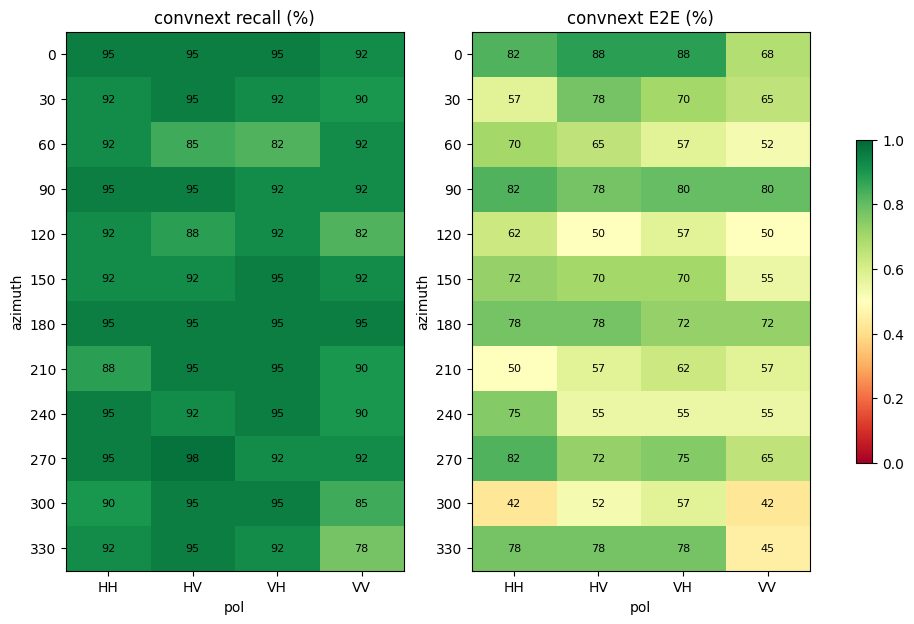

In [ ]:
import matplotlib.pyplot as plt

def heat(ax, piv, title):
    im = ax.imshow(piv.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
    ax.set_xlabel("pol"); ax.set_ylabel("azimuth"); ax.set_title(title)
    for r in range(piv.shape[0]):
        for c in range(piv.shape[1]):
            v = piv.values[r,c]
            if not np.isnan(v): ax.text(c, r, f"{v*100:.0f}", ha="center", va="center", fontsize=8)
    return im

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
heat(axes[0], df.pivot_table(index="azi", columns="pol", values="recall"), f"{MODEL_TAG} recall (%)")
im = heat(axes[1], df.pivot_table(index="azi", columns="pol", values="E2E"), f"{MODEL_TAG} E2E (%)")
fig.colorbar(im, ax=axes, shrink=0.6); plt.show()

## 해석 가이드
- **방위각 행이 고르게 초록** → 회전 보정이 48장 전반에서 작동 (90°배수 + off-axis 모두)
- **off-axis(60/120/210/240/300)가 낮으면** → 90° 스냅의 30° 잔차 + 산란 이방성 (회전으로 못 고치는 물리 한계)
- **VV 열만 낮으면** → VV 후방산란 약세 (recall부터 낮은지 확인)

## 비교/다음 단계
- 셀 3에서 분류기만 바꿔 재실행하면 `dom48_resnet18.csv` / `dom48_convnext.csv`로 자동 분리 저장 → 모델 비교
- 참고 확정 수치(48장 평균): ConvNeXt E2E 0.618 / ResNet18 E2E 0.501